In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

def plot_saved_outputs(save_dir, laser_num, N_step=None):
    # Load data
    x_path = os.path.join(save_dir, f"x_outputs_laser_{laser_num}.csv")
    u_path = os.path.join(save_dir, f"u_outputs_laser_{laser_num}.csv")
    ref_path = os.path.join(save_dir, f"ref_laser_{laser_num}.csv")

    try:
        x = pd.read_csv(x_path).values
        u = pd.read_csv(u_path).values
        ref = pd.read_csv(ref_path).values.flatten()

        if N_step is None:
            N_step = min(len(x), len(u), len(ref))

        plt.figure(figsize=[8, 6])
        plt.suptitle(f"Laser Power Number: {laser_num}", fontsize=14)

        # ─── 1. Melt Pool Temperature ──────────────────────────────
        plt.subplot(3, 1, 1)
        plt.plot(x[:N_step, 0], label="GAMMA simulation")
        plt.plot(ref[:N_step], label="Reference")
        #for yline in [2000, 3000, 4000]:
            #plt.axhline(y=yline, color='gray', linestyle='--', linewidth=0.8)
        plt.legend()
        plt.xlabel("MPC time step")
        plt.xlim(4150, 4950)
        plt.ylabel("Melt Pool Temp (K)")

        # ─── 2. Melt Pool Depth ───────────────────────────────────
        plt.subplot(3, 1, 2)
        plt.plot(x[:N_step, 1], label="GAMMA simulation")
        plt.axhline(y=0.225, linestyle='--', color='r', label="Upper Bound")
        plt.axhline(y=0.075, linestyle='--', color='r', label="Lower Bound")
        plt.legend()
        plt.xlim(4150, 4950)
        plt.xlabel("MPC time step")
        plt.ylabel("Melt Pool Depth (mm)")

        # ─── 3. Laser Power ───────────────────────────────────────
        plt.subplot(3, 1, 3)
        plt.plot(u[:N_step])
        #for yline in [500, 600, 700]:
            #plt.axhline(y=yline, color='gray', linestyle='--', linewidth=0.8)
        plt.xlabel("MPC time step")
        plt.ylabel("Laser Power (W)")
        plt.xlim(4150, 4950)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    except Exception as e:
        print(f"❌ Failed to plot for laser {laser_num}: {e}")



📌 Found laser_power_numbers: [2, 3, 4, 5, 6, 7, 8, 9, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 42, 43, 44, 50, 51, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]


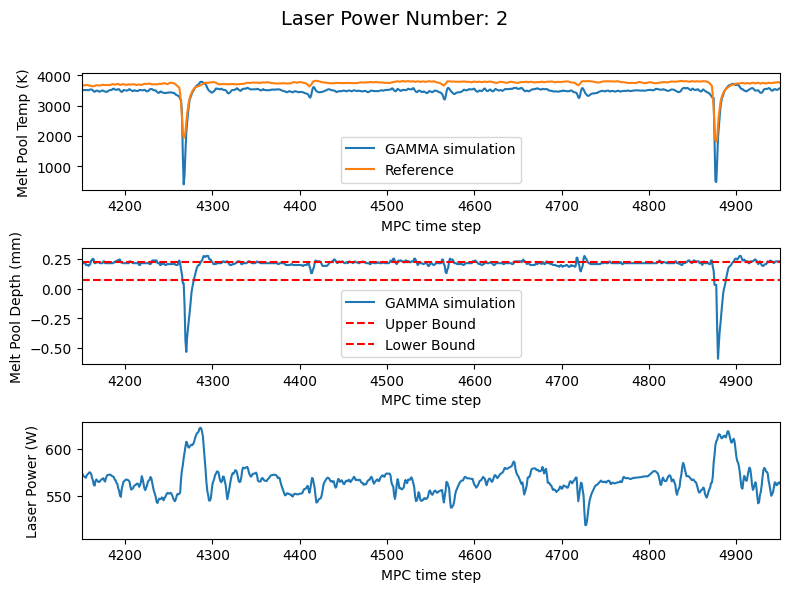

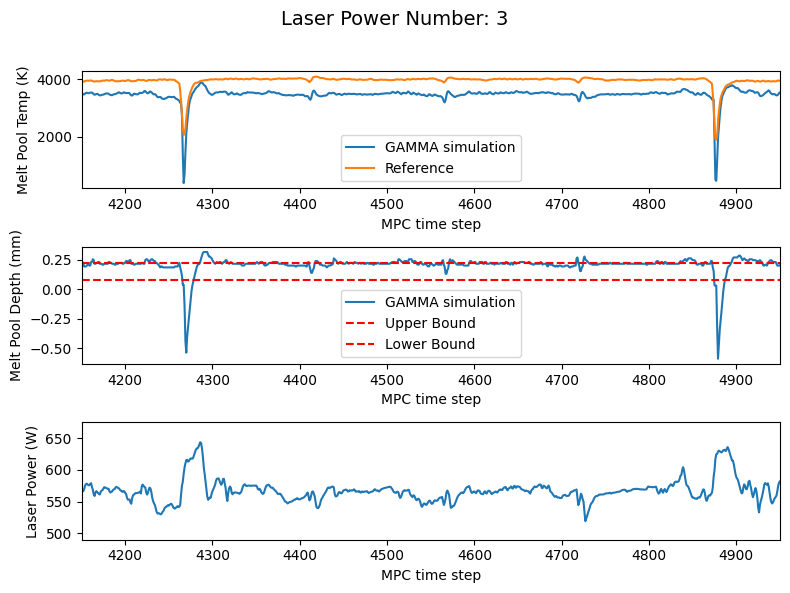

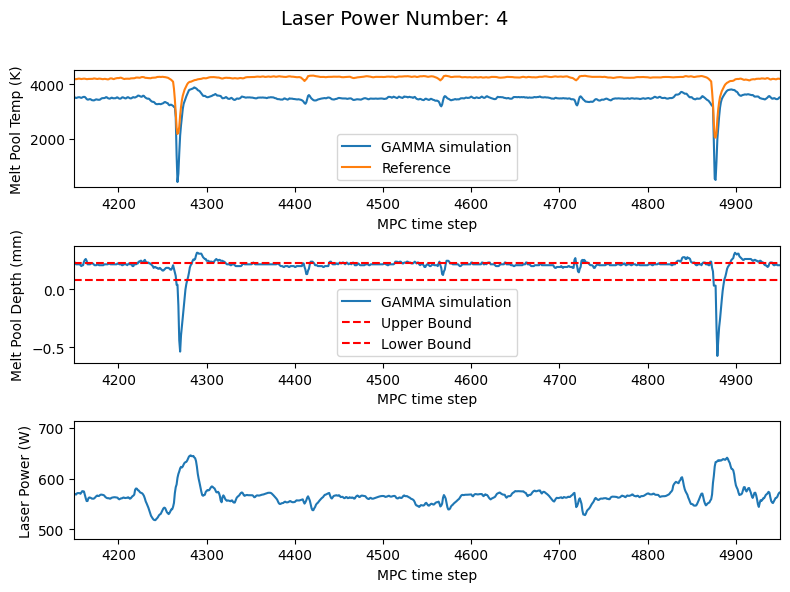

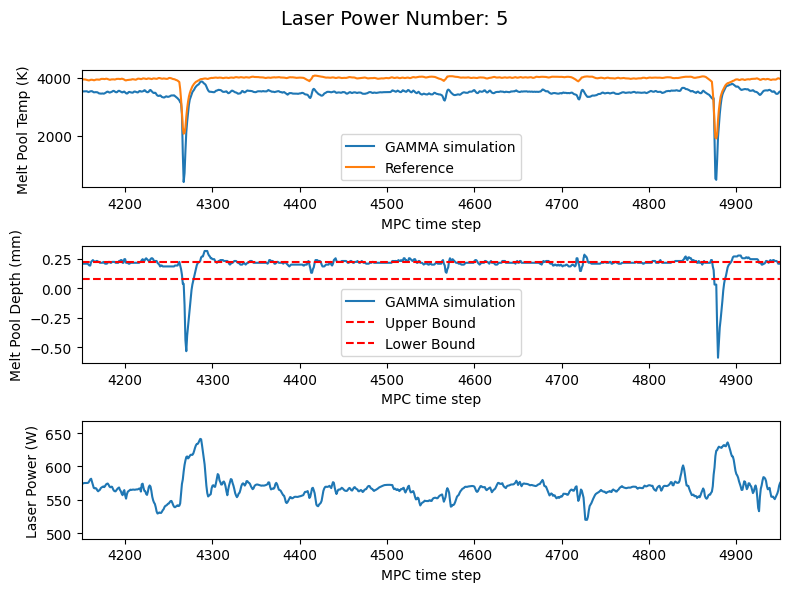

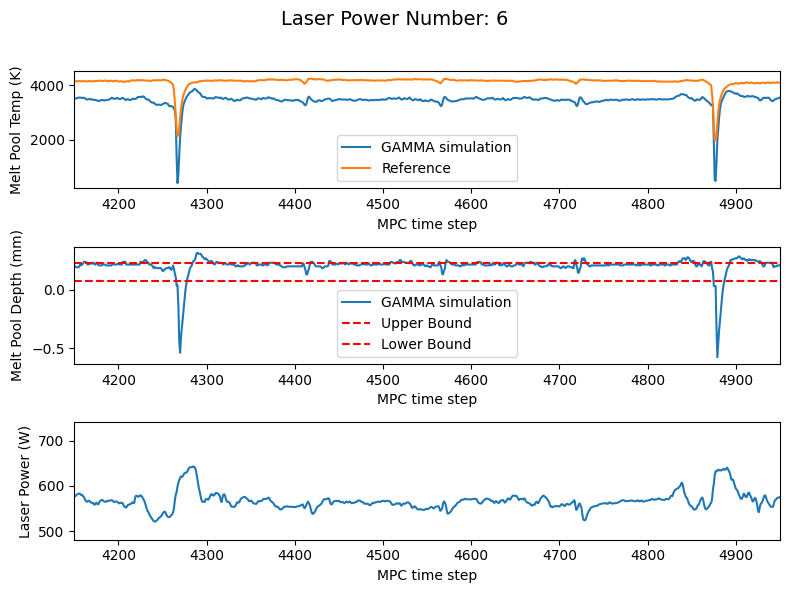

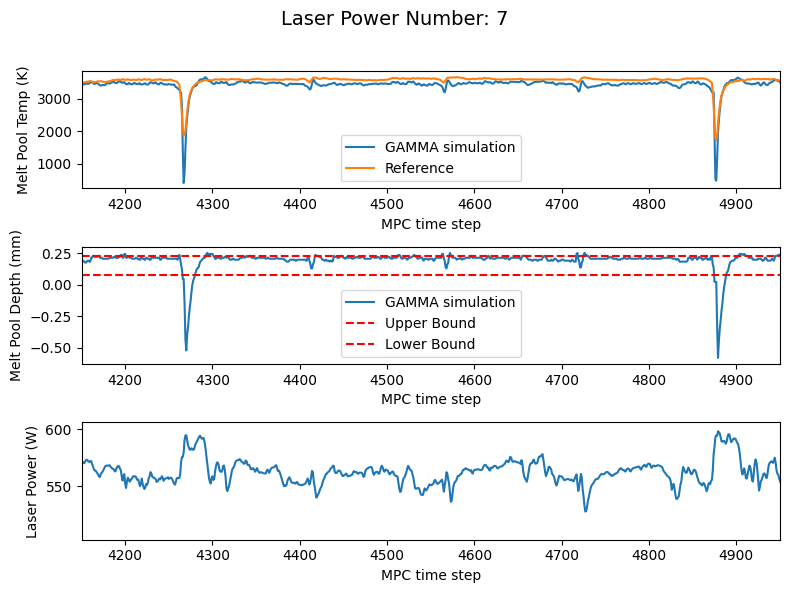

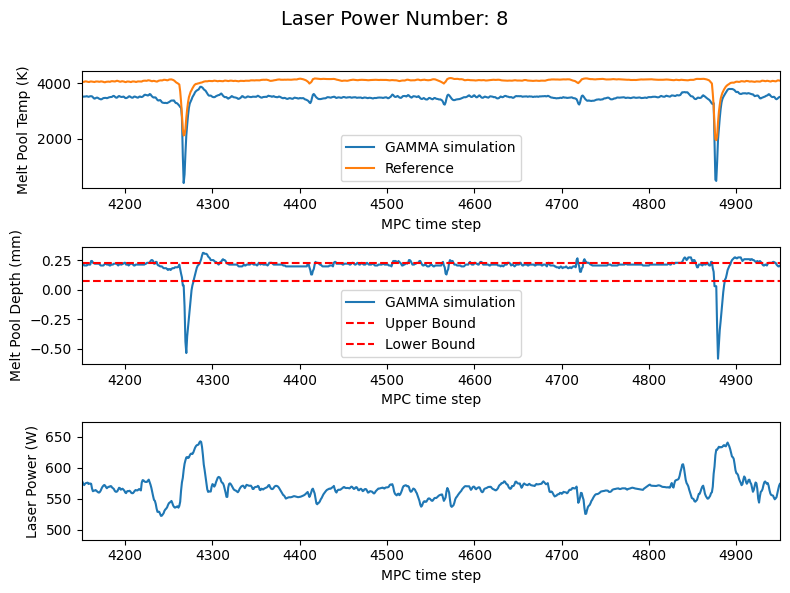

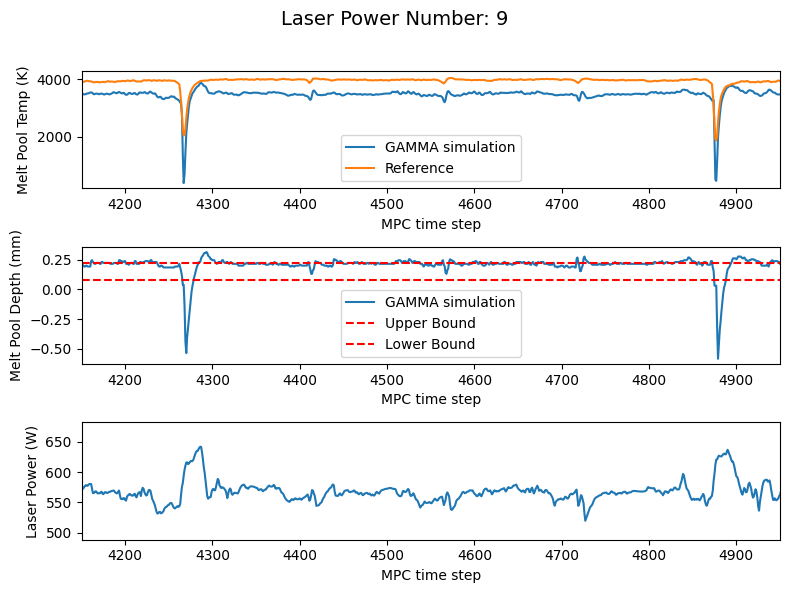

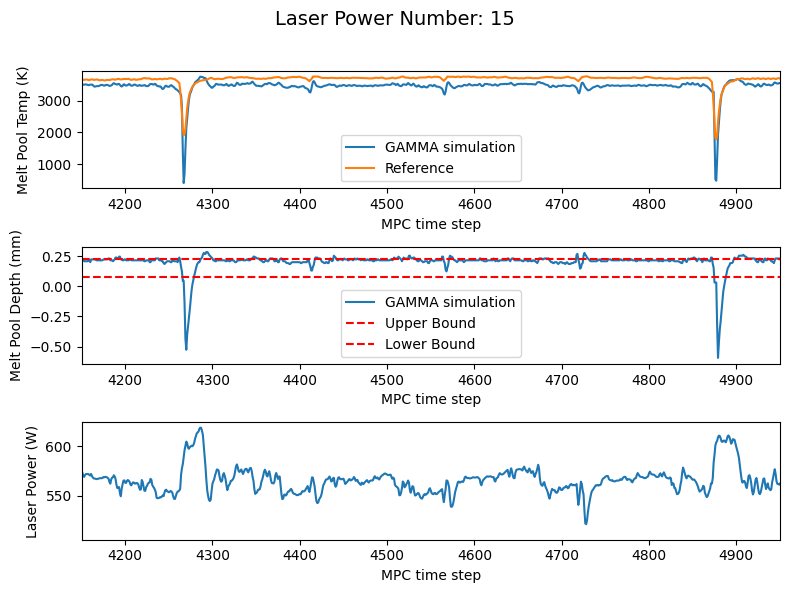

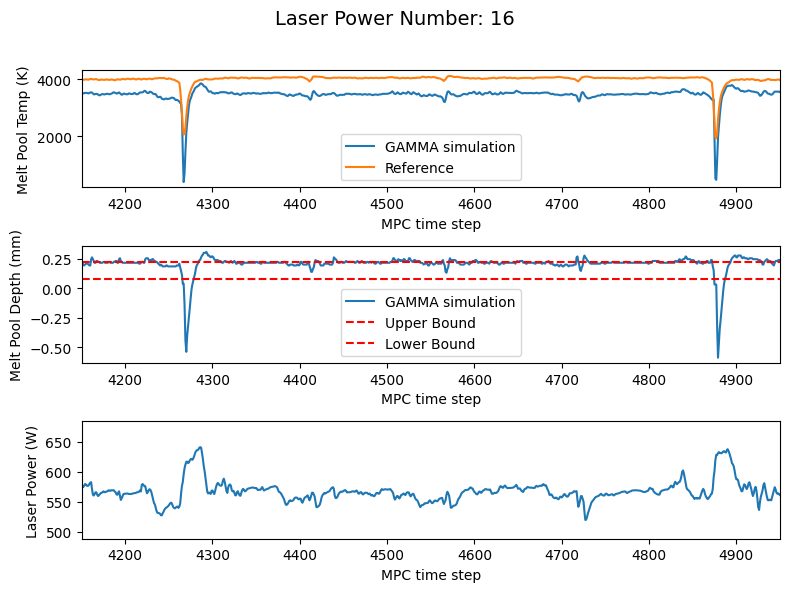

In [ ]:
# ── Main Loop ───────────────────────────────────────────────
save_dir = "/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case21_discrete shift"

# Find laser_power_numbers
all_files = os.listdir(save_dir)
laser_nums = sorted(set(
    int(re.search(r"(\d+)", f).group(1))
    for f in all_files if f.startswith("x_outputs_laser_")
))

print(f"📌 Found laser_power_numbers: {laser_nums}")

# Plot all
for laser_num in laser_nums:
    plot_saved_outputs(save_dir, laser_num)